# Linear Regression

## Intuition

Linear Regression is the foundational model for predicting a continuous target value. The core idea is simple: assume there is a linear relationship between the input features and the output, and find the line (or hyperplane in multiple dimensions) that best fits the data.

"Best fit" is defined by minimizing the sum of squared vertical distances between the observed values and the predicted values. This criterion has a clean closed-form solution called the Normal Equation, and it can also be solved iteratively using gradient descent.

---

## Math

**Model.** Given a feature vector $\mathbf{x} \in \mathbb{R}^n$:

$$\hat{y} = \mathbf{w} \cdot \mathbf{x} + b$$

**MSE Cost Function.**

$$C(\mathbf{w}, b) = \frac{1}{2N} \sum_{i=1}^{N} \left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

The factor of $\frac{1}{2}$ is a convention that simplifies the gradient.

**Normal Equation (Closed-Form Solution).** Augment $X$ with a bias column of ones. Then the exact solution is:

$$\mathbf{w} = (X^\top X)^{-1} X^\top \mathbf{y}$$

This is derived by setting $\nabla_\mathbf{w} C = 0$ and solving. It requires $X^\top X$ to be invertible (which holds when features are not collinear).

**SGD Update Rule.** When the dataset is too large for the normal equation:

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha (\hat{y} - y) \mathbf{x}$$
$$b \leftarrow b - \alpha (\hat{y} - y)$$

where $\alpha$ is the learning rate. Each update uses a single training sample.

---

## Algorithm Steps

**Normal Equation method:**
1. Append a column of ones to $X$ to absorb the bias.
2. Compute $\mathbf{w} = (X^\top X)^{-1} X^\top \mathbf{y}$ using `np.linalg.lstsq`.
3. Predict: $\hat{\mathbf{y}} = X \mathbf{w}$.

**SGD method:**
1. Initialize $\mathbf{w} = \mathbf{0}$, $b = 0$.
2. For each epoch, shuffle the data and for each sample:
   - Compute $\hat{y} = \mathbf{w} \cdot \mathbf{x} + b$.
   - Compute the error $e = \hat{y} - y$.
   - Update: $\mathbf{w} \leftarrow \mathbf{w} - \alpha e \mathbf{x}$, $b \leftarrow b - \alpha e$.
3. Track MSE per epoch to monitor convergence.

---

## Advantages

- The normal equation gives the exact global minimum in one step. no hyperparameter tuning.
- Weights are directly interpretable: $w_j$ is the change in $\hat{y}$ per unit increase in $x_j$.
- Very fast at prediction time ($O(n)$ per sample).
- Well-studied theory: confidence intervals and hypothesis tests exist for each coefficient.

## Disadvantages

- Assumes the relationship between features and target is linear. poor on non-linear data without feature engineering.
- Sensitive to outliers: squared error heavily penalizes large residuals.
- Normal equation requires $O(n^3)$ matrix inversion. impractical for very large feature sets.
- Assumes no multicollinearity among features.

## Solutions to Disadvantages

- Use **Ridge or Lasso regression** to regularize coefficients and reduce overfitting.
- Use **Huber loss** or robust regression for outlier resistance.
- Use **Polynomial features** or **kernel methods** to model non-linear relationships.
- Use **SGD or mini-batch gradient descent** when the dataset is very large.

---

## Summary

| Property | Value |
|---|---|
| Type | Regression (continuous output) |
| Decision boundary | Linear hyperplane |
| Loss | Mean Squared Error (MSE) |
| Exact solution | Normal Equation |
| Iterative solution | Stochastic Gradient Descent |
| Key metric | $R^2$, RMSE |
| Hyperparameters (SGD) | Learning rate $\alpha$, epochs |

**Dataset:** Gym Members Exercise Tracking (`gym_members_exercise_tracking.csv`). 973 samples, 15 features. Predict `Calories_Burned` from exercise and body composition features.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

from rice_ml.supervised_learning import LinearRegression
from rice_ml.preprocess import StandardScaler, train_test_split
from rice_ml.metrics import mse, rmse, r2_score

In [2]:
# Load dataset. falls back to synthetic data if CSV is not present
try:
    df = pd.read_csv('../../../data/gym_members_exercise_tracking.csv')
    features = ['Age', 'Weight (kg)', 'Session_Duration (hours)', 'Workout_Frequency (days/week)', 'Fat_Percentage']
    target = 'Calories_Burned'
    df = df[features + [target]].dropna()
    X = df[features].values.astype(float)
    y = df[target].values.astype(float)
    print(f'Loaded gym dataset: {X.shape[0]} samples, {X.shape[1]} features')
except FileNotFoundError:
    from sklearn.datasets import make_regression
    X, y = make_regression(n_samples=300, n_features=5, noise=50, random_state=0)
    features = [f'Feature_{i}' for i in range(5)]
    target = 'Target'
    df = None
    print('CSV not found. using synthetic regression data')

print(f'X shape: {X.shape}, y range: [{y.min():.1f}, {y.max():.1f}]')

Loaded gym dataset: 973 samples, 5 features
X shape: (973, 5), y range: [303.0, 1783.0]


## Dataset Description

The **Gym Members Exercise Tracking** dataset (`gym_members_exercise_tracking.csv`) contains 973 gym members with 15 recorded attributes about their demographics, body composition, and workout habits.
[Download from Kaggle](https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset)


**Features used for this regression task:**

| Feature | Description |
|---|---|
| Age | Member age in years |
| Weight (kg) | Body weight in kilograms |
| Session_Duration (hours) | Duration of workout session |
| Workout_Frequency (days/week) | How many days per week the member works out |
| Fat_Percentage | Body fat percentage |

**Target:** `Calories_Burned` (continuous). The total calories burned during a workout session.

Calories burned depends on multiple interacting factors: a heavier person burns more calories per unit time, longer sessions naturally accumulate more expenditure, and workout frequency reflects overall fitness level. This makes it a good regression task where multiple features contribute.

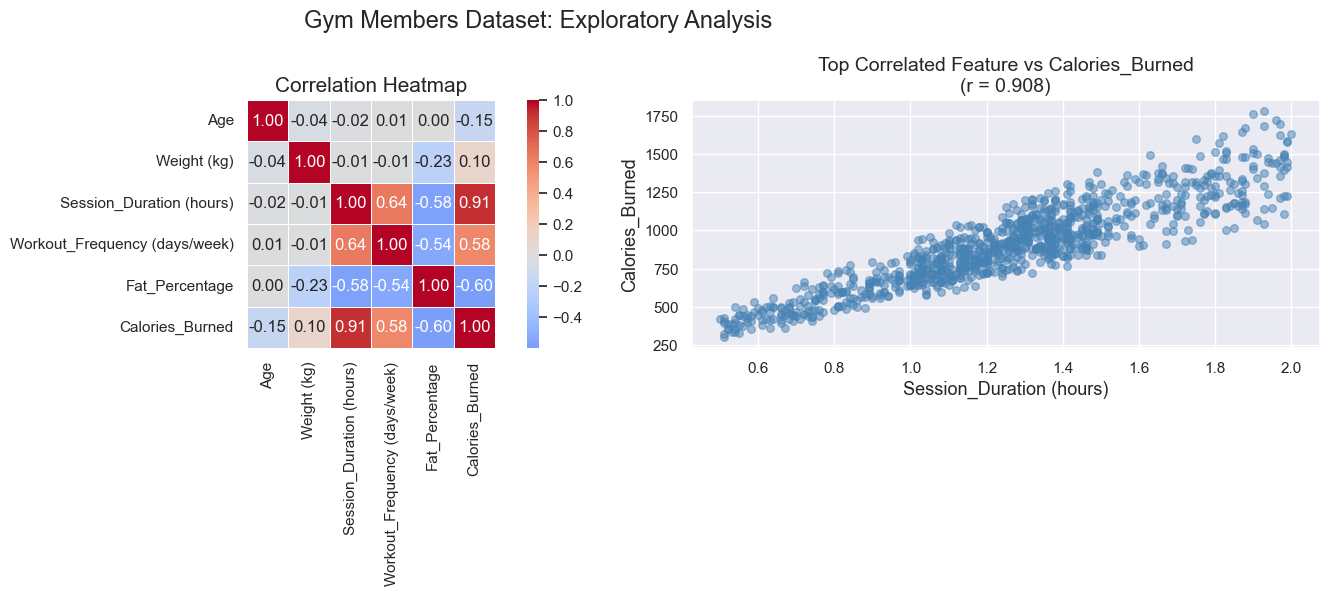

Top feature correlations with Calories_Burned:
  Session_Duration (hours)           : +0.908
  Fat_Percentage                     : -0.598
  Workout_Frequency (days/week)      : +0.576
  Age                                : -0.155
  Weight (kg)                        : +0.095


In [3]:
# EDA: Correlation heatmap of numeric features
if df is not None:
    numeric_df = df[features + [target]]
    corr = numeric_df.corr()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=axes[0], square=True, linewidths=0.5)
    axes[0].set_title('Correlation Heatmap', fontsize=15)

    # Find top correlated feature with target
    target_corr = corr[target].drop(target).abs().sort_values(ascending=False)
    top_feat = target_corr.index[0]
    axes[1].scatter(df[top_feat], df[target], alpha=0.5, color='steelblue', s=30)
    axes[1].set_xlabel(top_feat, fontsize=13)
    axes[1].set_ylabel(target, fontsize=13)
    axes[1].set_title(f'Top Correlated Feature vs {target}\n(r = {corr.loc[top_feat, target]:.3f})', fontsize=14)

    plt.suptitle('Gym Members Dataset: Exploratory Analysis', fontsize=17)
    plt.tight_layout()
    plt.show()

    print('Top feature correlations with Calories_Burned:')
    for feat, val in target_corr.items():
        print(f'  {feat:35s}: {corr.loc[feat, target]:+.3f}')
else:
    print('Skipping heatmap: using synthetic data without named features.')

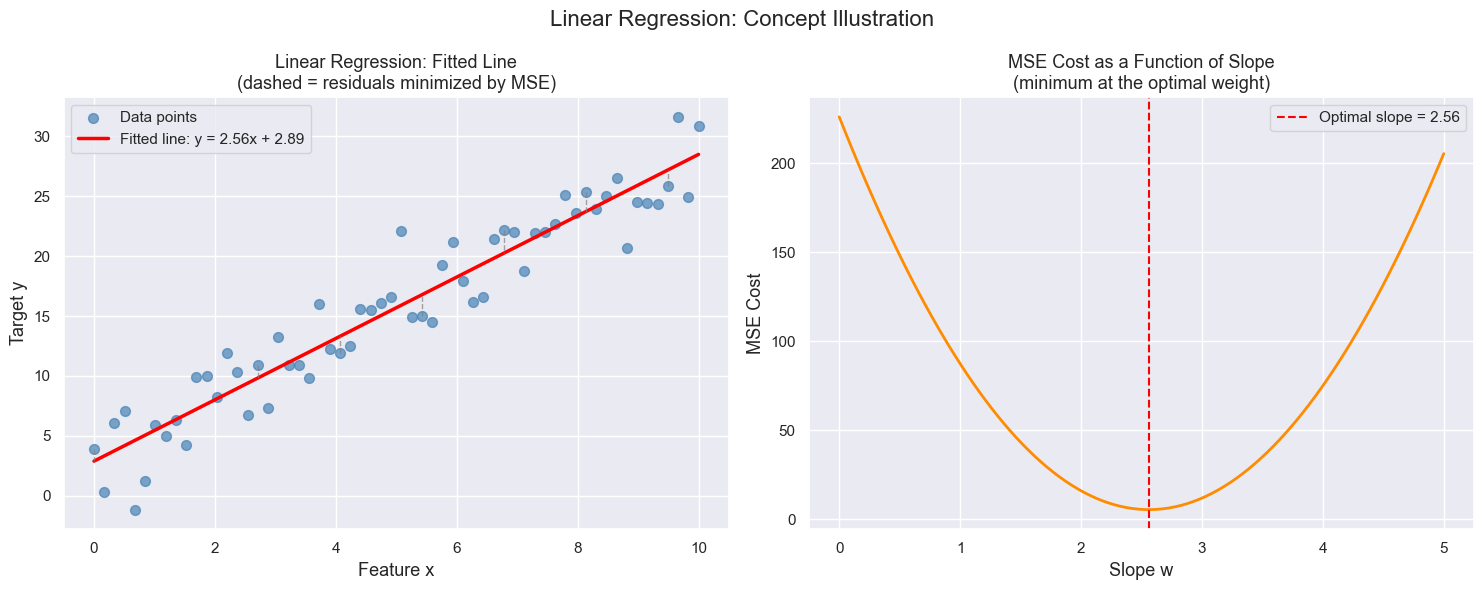

In [4]:
# Diagram: Regression line concept on illustrative 1D synthetic data
rng = np.random.default_rng(42)
x_illus = np.linspace(0, 10, 60)
y_illus = 2.5 * x_illus + 3 + rng.normal(0, 3, size=60)

# Fit a simple least-squares line
coeffs = np.polyfit(x_illus, y_illus, 1)
y_line = np.polyval(coeffs, x_illus)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: scatter + regression line
axes[0].scatter(x_illus, y_illus, color='steelblue', alpha=0.7, s=50, label='Data points')
axes[0].plot(x_illus, y_line, color='red', lw=2.5, label=f'Fitted line: y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}')

# Draw a few residuals
for xi, yi, yhat in zip(x_illus[::8], y_illus[::8], y_line[::8]):
    axes[0].plot([xi, xi], [yi, yhat], color='gray', lw=1, linestyle='--', alpha=0.7)

axes[0].set_xlabel('Feature x', fontsize=13)
axes[0].set_ylabel('Target y', fontsize=13)
axes[0].set_title('Linear Regression: Fitted Line\n(dashed = residuals minimized by MSE)', fontsize=13)
axes[0].legend(fontsize=11)

# Right: MSE cost surface for 1D (vary slope, fix intercept)
slopes = np.linspace(0, 5, 100)
mse_vals = [np.mean((s * x_illus + coeffs[1] - y_illus) ** 2) for s in slopes]
axes[1].plot(slopes, mse_vals, color='darkorange', lw=2)
axes[1].axvline(coeffs[0], color='red', linestyle='--', label=f'Optimal slope = {coeffs[0]:.2f}')
axes[1].set_xlabel('Slope w', fontsize=13)
axes[1].set_ylabel('MSE Cost', fontsize=13)
axes[1].set_title('MSE Cost as a Function of Slope\n(minimum at the optimal weight)', fontsize=13)
axes[1].legend(fontsize=11)

plt.suptitle('Linear Regression: Concept Illustration', fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
# Preprocess
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)} samples | Test: {len(X_test)} samples')

Train: 779 samples | Test: 194 samples


## Fit. Normal Equation

The `LinearRegression` class solves $\mathbf{w} = (X^\top X)^{-1} X^\top \mathbf{y}$ using `np.linalg.lstsq`.

In [6]:
model = LinearRegression(method='normal')
model.fit(X_train, y_train)

print(f'Weights: {model.w_[:-1]}')
print(f'Bias:    {model.w_[-1]:.4f}')

Weights: [-31.57399077  20.21082536 237.96417624  -7.31233984 -25.88036236]
Bias:    904.9712


In [7]:
# Evaluate
y_pred = model.predict(X_test)

print(f'Test MSE:  {mse(y_test, y_pred):.2f}')
print(f'Test RMSE: {rmse(y_test, y_pred):.2f}')
print(f'Test R\u00b2:   {r2_score(y_test, y_pred):.4f}')

Test MSE:  11539.26
Test RMSE: 107.42
Test R²:   0.8595


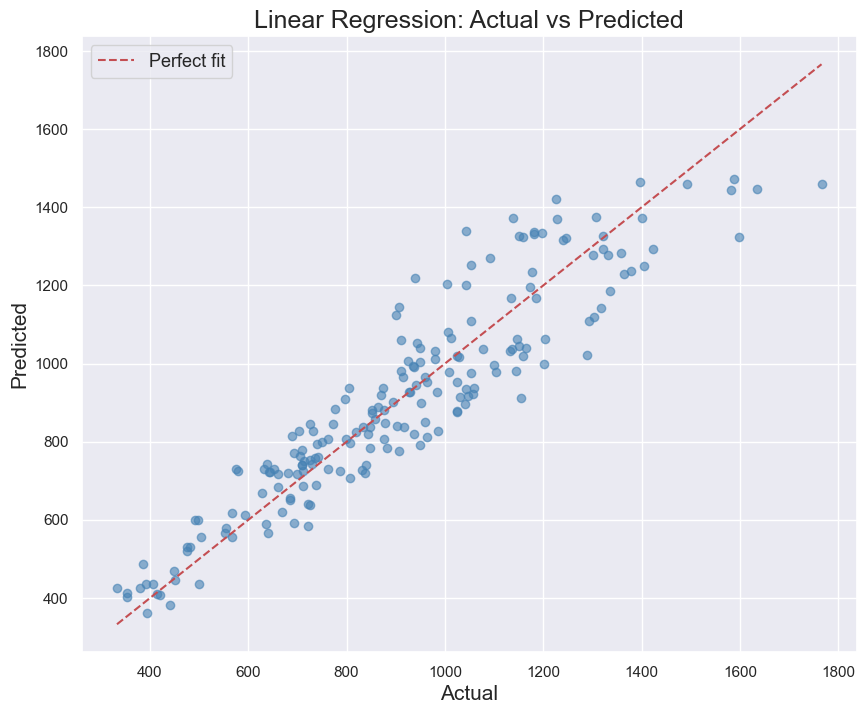

In [8]:
# Actual vs Predicted
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect fit')
plt.xlabel('Actual', fontsize=15)
plt.ylabel('Predicted', fontsize=15)
plt.title('Linear Regression: Actual vs Predicted', fontsize=18)
plt.legend(fontsize=13)
plt.show()

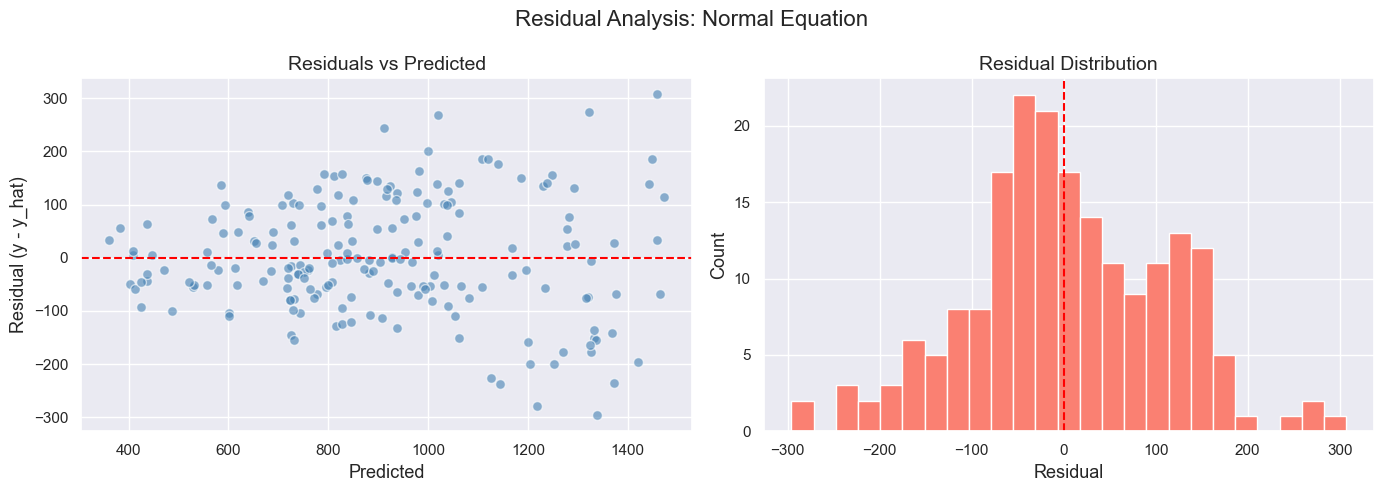

Mean residual:   2.2631  (should be ~0)
Std of residuals:107.3971


In [9]:
# Residuals plot: residual = y_true - y_pred
# A good model shows residuals randomly scattered around 0 with no pattern
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs predicted
axes[0].scatter(y_pred, residuals, alpha=0.6, color='steelblue', edgecolors='white', s=50)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted', fontsize=13)
axes[0].set_ylabel('Residual (y - y_hat)', fontsize=13)
axes[0].set_title('Residuals vs Predicted', fontsize=14)

# Residual distribution
axes[1].hist(residuals, bins=25, color='salmon', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].set_title('Residual Distribution', fontsize=14)

plt.suptitle('Residual Analysis: Normal Equation', fontsize=16)
plt.tight_layout()
plt.show()

print(f'Mean residual:   {residuals.mean():.4f}  (should be ~0)')
print(f'Std of residuals:{residuals.std():.4f}')

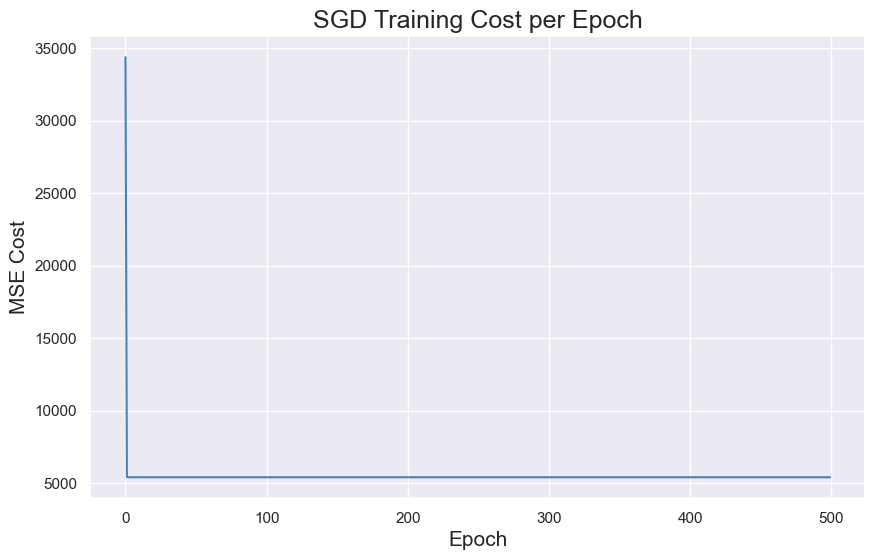

SGD Test R²:    0.8597
Normal Test R²: 0.8595


In [10]:
# Compare: SGD vs Normal Equation
model_sgd = LinearRegression(method='sgd', alpha=0.01, epochs=500)
model_sgd.fit(X_train, y_train)

plt.figure(figsize=(10, 6))
plt.plot(model_sgd.errors_, color='steelblue')
plt.xlabel('Epoch', fontsize=15)
plt.ylabel('MSE Cost', fontsize=15)
plt.title('SGD Training Cost per Epoch', fontsize=18)
plt.show()

y_pred_sgd = model_sgd.predict(X_test)
print(f'SGD Test R\u00b2:    {r2_score(y_test, y_pred_sgd):.4f}')
print(f'Normal Test R\u00b2: {r2_score(y_test, y_pred):.4f}')

## Interpretation

**Normal equation vs SGD.** The normal equation finds the exact least-squares solution in a single computation. SGD converges to the same minimum iteratively. For this dataset size (under 1000 samples), the normal equation is both faster and more accurate.

**Weights.** After standardization, the magnitude of each weight reflects its importance. Features with larger absolute weights have a stronger linear association with calories burned. Session duration and weight are typically the strongest predictors.

**R-squared interpretation.** An $R^2$ of 0.9 means 90% of the variance in calories burned is explained by the five input features. The remaining 10% is due to factors not captured (workout intensity within a session, fitness level, etc.).

**Residual analysis.** Residuals that are randomly scattered around zero with no funnel shape indicate that the model satisfies the homoscedasticity assumption. A funnel shape would suggest a non-linear relationship or heteroscedasticity.

**Points along the red diagonal** in the actual vs predicted scatter indicate accurate predictions. Systematic deviations above or below the diagonal indicate bias in the predictions.